# High-Value Customer Churn Prediction & Retention Strategy

**Author:** Samarjit Kabadi

**Business question:** which high-value prepaid subscribers are likely to churn next month, and is it worth paying to keep them?

**Approach in one line:** use behaviour in the *good phase* (months 6–7) and the *action phase* (month 8) to predict usage-based churn in month 9, choose the alert threshold on a validation set, report honest hold-out results, explain the drivers with SHAP, and translate the model into a retention budget decision.

| Section | What it does |
|---|---|
| 1 | Load data, isolate high-value customers, define churn |
| 2 | Clean data and engineer behavioural "velocity" features |
| 3 | Exploratory analysis |
| 4 | Train / validation / test split |
| 5 | Model comparison using leak-free scikit-learn pipelines |
| 6 | Threshold selection on the validation set (F2) |
| 7 | Final hold-out evaluation |
| 8 | Explainability with SHAP |
| 9 | Cost–benefit of the retention campaign |
| 10 | Export risk scores and query them with SQL (DuckDB) |

In [1]:
import warnings
import zipfile
from pathlib import Path

warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", message=".*penalty is deprecated.*")

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, confusion_matrix, fbeta_score,
                             precision_recall_curve, precision_score, recall_score,
                             roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 50)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
DATA_ZIP = "telecom_churn_data.csv.zip"   # read straight from the zip in the repo, no unzipping needed
IMG_DIR = Path("images"); IMG_DIR.mkdir(exist_ok=True)
OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)

## 1. Load data, isolate high-value customers, define churn

* **High-value customers (HVC):** average recharge amount in months 6–7 at or above the 70th percentile (the top ~30% of the base).
* **Churn (month 9):** zero incoming calls, zero outgoing calls and zero 2G/3G data. Prepaid customers leave silently, so churn is defined by usage.
* All month-9 columns are then removed, because they would not exist at prediction time.

In [2]:
with zipfile.ZipFile(DATA_ZIP) as z:
    raw = pd.read_csv(z.open("telecom_churn_data.csv"))
print(f"Raw data: {raw.shape[0]:,} subscribers x {raw.shape[1]} columns")

avg_rech_good = raw[["total_rech_amt_6", "total_rech_amt_7"]].fillna(0).mean(axis=1)
hvc_cutoff = avg_rech_good.quantile(0.70)
hvc = raw[avg_rech_good >= hvc_cutoff].copy()

hvc["churn"] = ((hvc["total_ic_mou_9"] == 0) & (hvc["total_og_mou_9"] == 0)
                & (hvc["vol_2g_mb_9"] == 0) & (hvc["vol_3g_mb_9"] == 0)).astype(int)
hvc = hvc.drop(columns=[c for c in hvc.columns if c.endswith("_9")])

print(f"HVC recharge cut-off (70th percentile): INR {hvc_cutoff:,.0f}")
print(f"High-value customers: {len(hvc):,}")
print(f"Churn rate: {hvc['churn'].mean():.2%}")

Raw data: 99,999 subscribers x 226 columns
HVC recharge cut-off (70th percentile): INR 368
High-value customers: 30,011
Churn rate: 8.64%


## 2. Cleaning and feature engineering

Every step here is row-wise (no statistics learned from the whole dataset), so it is safe to run before the split.
Anything that *learns* from data, such as outlier caps, scaling and PCA, lives inside the model pipelines in Section 5.

**Design decision: usage-only model.** Recharge amount and ARPU columns are excluded from the features. In month 8 they
largely restate the outcome (a customer who is leaving stops recharging), so a usage-only model gives an earlier,
behavioural warning signal. ARPU is kept aside and used later to value the retention campaign. Section 5 shows the
performance cost of this choice.

In [3]:
REF_DATE = pd.Timestamp("2014-08-31")
df = hvc.copy()

# Recency: days since the last recharge, measured at the end of the action phase
recency = pd.DataFrame({
    f"days_since_{col.replace('date_of_', '')}": (REF_DATE - pd.to_datetime(df[col], format="%m/%d/%Y")).dt.days.fillna(99)
    for col in ["date_of_last_rech_8", "date_of_last_rech_data_8"]})
df = pd.concat([df.drop(columns=[c for c in df.columns if "date" in c]), recency], axis=1)

# Missing usage means no activity; missing flags mean the service was never used
usage_like = [c for c in df.columns if any(k in c for k in ["mou", "vol", "rech", "amt", "arpu", "count", "sachet", "monthly"])]
df[usage_like] = df[usage_like].fillna(0)
flag_cols = [c for c in df.columns if "fb_user" in c or "night_pck_user" in c]
df[flag_cols] = df[flag_cols].fillna(-1)
df = df.fillna(0)
df = df.loc[:, df.nunique() > 1]

# Velocity features: action-phase (month 8) level minus good-phase (months 6-7) average
def velocity(frame, cols6, cols7, cols8):
    good = (frame[cols6].sum(axis=1) + frame[cols7].sum(axis=1)) / 2
    return frame[cols8].sum(axis=1) - good

new_features = pd.DataFrame({
    "mou_velocity": velocity(df, ["total_ic_mou_6", "total_og_mou_6"], ["total_ic_mou_7", "total_og_mou_7"], ["total_ic_mou_8", "total_og_mou_8"]),
    "ic_mou_velocity": velocity(df, ["total_ic_mou_6"], ["total_ic_mou_7"], ["total_ic_mou_8"]),
    "offnet_ic_velocity": velocity(df, ["loc_ic_t2m_mou_6"], ["loc_ic_t2m_mou_7"], ["loc_ic_t2m_mou_8"]),
    "data_velocity": velocity(df, ["vol_2g_mb_6", "vol_3g_mb_6"], ["vol_2g_mb_7", "vol_3g_mb_7"], ["vol_2g_mb_8", "vol_3g_mb_8"]),
    "roam_velocity": velocity(df, ["roam_ic_mou_6", "roam_og_mou_6"], ["roam_ic_mou_7", "roam_og_mou_7"], ["roam_ic_mou_8", "roam_og_mou_8"]),
    "arpu_good": df[["arpu_6", "arpu_7"]].mean(axis=1),
})
df = pd.concat([df, new_features], axis=1)

# Keep ARPU aside for the business case; exclude revenue/recharge columns from the model
revenue_cols = [c for c in df.columns if any(k in c for k in ["arpu", "rech", "amt"])]
ID_COL, TARGET = "mobile_number", "churn"
FEATURES = [c for c in df.columns if c not in revenue_cols + [ID_COL, TARGET]]
FEATURES_WITH_REVENUE = [c for c in df.columns if c not in [ID_COL, TARGET, "arpu_good"]]

print(f"Model features (usage only): {len(FEATURES)}")
print(f"Revenue/recharge columns held out: {len(revenue_cols)}")

Model features (usage only): 121
Revenue/recharge columns held out: 39


## 3. Exploratory analysis
Churners show a sharp collapse in usage in the action phase, well before they go silent.

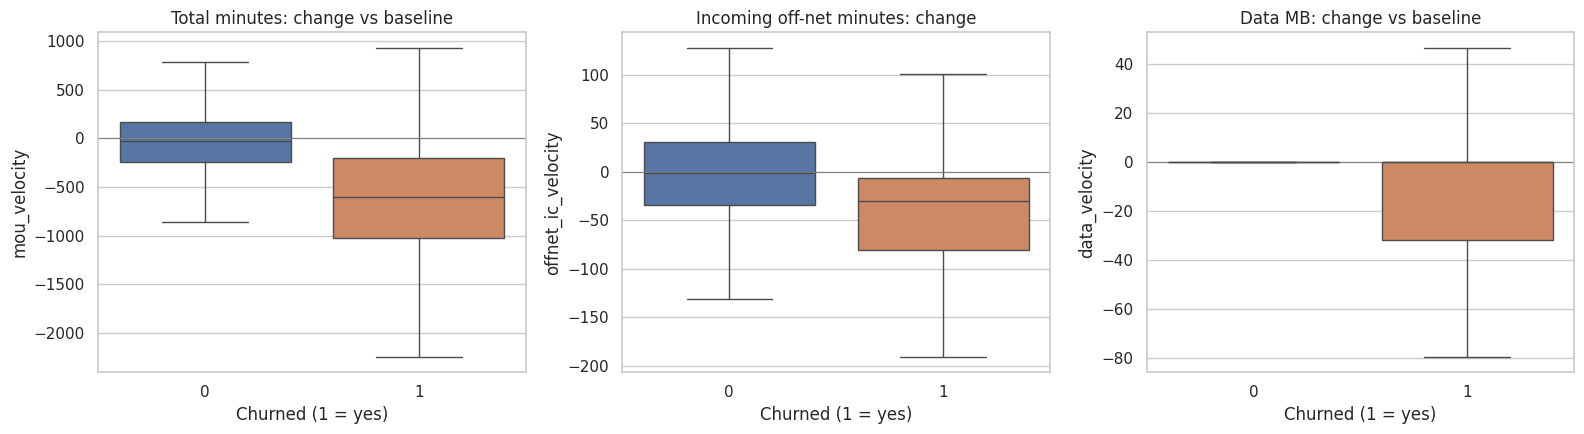

,mou_velocity,offnet_ic_velocity,data_velocity,days_since_last_rech_8
churn,,,,
0,-27.6,-1.3,0.0,2.0
1,-607.2,-29.9,0.0,6.0


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, title in zip(axes, ["mou_velocity", "offnet_ic_velocity", "data_velocity"],
                          ["Total minutes: change vs baseline", "Incoming off-net minutes: change", "Data MB: change vs baseline"]):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax, showfliers=False, hue=TARGET, palette=["#4C72B0", "#DD8452"], legend=False)
    ax.set_title(title); ax.set_xlabel("Churned (1 = yes)"); ax.axhline(0, color="grey", lw=0.8)
plt.tight_layout(); plt.savefig(IMG_DIR / "eda_velocity.png", dpi=120); plt.show()

df.groupby(TARGET)[["mou_velocity", "offnet_ic_velocity", "data_velocity", "days_since_last_rech_8"]].median().round(1)

## 4. Train / validation / test split (60 / 20 / 20, stratified)
* **Train:** fit the models.
* **Validation:** compare models and choose the alert threshold.
* **Test:** touched once, at the end, for the reported results.

In [5]:
X, y = df[FEATURES], df[TARGET]
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=0.25, stratify=y_tmp, random_state=RANDOM_STATE)
for name, part in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    print(f"{name:<11} {len(part):>6,} rows | churn rate {part.mean():.2%}")

Train       18,006 rows | churn rate 8.64%
Validation   6,002 rows | churn rate 8.63%
Test         6,003 rows | churn rate 8.65%


## 5. Model comparison with leak-free pipelines
Outlier capping, scaling and PCA are fitted on the training data only, inside each pipeline.
Models are compared on the validation set using **PR-AUC** (average precision), which suits a ~9% minority class better than accuracy.

In [6]:
class QuantileCapper(BaseEstimator, TransformerMixin):
    """Caps each column at a quantile learned from the training data only."""
    def __init__(self, q=0.99):
        self.q = q
    def fit(self, X, y=None):
        self.caps_ = np.nanquantile(np.asarray(X, dtype=float), self.q, axis=0)
        return self
    def transform(self, X):
        return np.minimum(np.asarray(X, dtype=float), self.caps_)

models = {
    "Logistic regression + PCA (baseline)": Pipeline([
        ("cap", QuantileCapper()), ("scale", StandardScaler()), ("pca", PCA(n_components=0.90, random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=2000))]),
    "Lasso logistic regression": Pipeline([
        ("cap", QuantileCapper()), ("scale", StandardScaler()),
        ("clf", LogisticRegression(penalty="l1", solver="liblinear", C=0.1, class_weight="balanced"))]),
    "Random forest": Pipeline([
        ("cap", QuantileCapper()),
        ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=5, class_weight="balanced_subsample",
                                       n_jobs=-1, random_state=RANDOM_STATE))]),
    "Gradient boosting": Pipeline([
        ("cap", QuantileCapper()),
        ("clf", GradientBoostingClassifier(n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8,
                                           random_state=RANDOM_STATE))]),
}

rows = []
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    p_val = pipe.predict_proba(X_val)[:, 1]
    rows.append({"model": name, "val_pr_auc": average_precision_score(y_val, p_val), "val_roc_auc": roc_auc_score(y_val, p_val)})
comparison = pd.DataFrame(rows).sort_values("val_pr_auc", ascending=False).reset_index(drop=True)
comparison.round(3)

,model,val_pr_auc,val_roc_auc
0,Random forest,0.676,0.920
1,Gradient boosting,0.660,0.923
2,Lasso logistic regression,0.474,0.885
3,Logistic regression + PCA (baseline),0.465,0.885


In [7]:
# Sensitivity check: how much does excluding revenue/recharge features cost?
Xr_train = df.loc[X_train.index, FEATURES_WITH_REVENUE]; Xr_val = df.loc[X_val.index, FEATURES_WITH_REVENUE]
gb_rev = Pipeline([("cap", QuantileCapper()), ("clf", GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4, subsample=0.8, random_state=RANDOM_STATE))]).fit(Xr_train, y_train)
p_rev = gb_rev.predict_proba(Xr_val)[:, 1]
print(f"Gradient boosting WITH revenue features  - validation PR-AUC: {average_precision_score(y_val, p_rev):.3f}")
print(f"Gradient boosting usage-only (chosen)    - validation PR-AUC: {comparison.loc[comparison.model == 'Gradient boosting', 'val_pr_auc'].item():.3f}")

Gradient boosting WITH revenue features  - validation PR-AUC: 0.696
Gradient boosting usage-only (chosen)    - validation PR-AUC: 0.660


## 6. Threshold selection on the validation set
Missing a high-value churner costs far more than an unnecessary retention offer, so the threshold maximises the
**F2-score** (recall weighted twice as heavily as precision). The threshold is chosen on validation data only.

Selected model: Random forest
F2-optimal threshold (validation): 0.239 | val recall 78.76% | val precision 45.23%


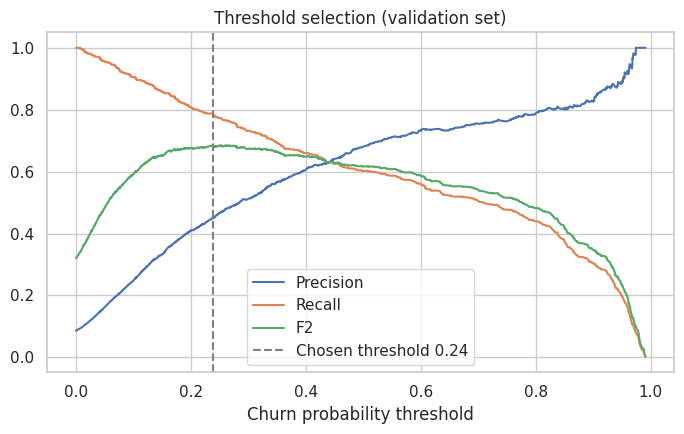

In [8]:
best_name = comparison.loc[0, "model"]
best_model = models[best_name]
p_val = best_model.predict_proba(X_val)[:, 1]

prec, rec, thr = precision_recall_curve(y_val, p_val)
f2 = (5 * prec * rec) / (4 * prec + rec + 1e-12)
best_idx = np.nanargmax(f2[:-1])
THRESHOLD = float(thr[best_idx])
print(f"Selected model: {best_name}")
print(f"F2-optimal threshold (validation): {THRESHOLD:.3f} | val recall {rec[best_idx]:.2%} | val precision {prec[best_idx]:.2%}")

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thr, prec[:-1], label="Precision"); ax.plot(thr, rec[:-1], label="Recall"); ax.plot(thr, f2[:-1], label="F2")
ax.axvline(THRESHOLD, color="grey", ls="--", label=f"Chosen threshold {THRESHOLD:.2f}")
ax.set_xlabel("Churn probability threshold"); ax.set_title("Threshold selection (validation set)"); ax.legend()
plt.tight_layout(); plt.savefig(IMG_DIR / "threshold_selection.png", dpi=120); plt.show()

## 7. Final evaluation on the untouched test set
Accuracy is shown for completeness only: predicting "no churn" for everyone would already score ~91%.

Recall (churners caught)                     0.830
Precision (alerts that are real churners)    0.455
F2-score                                     0.713
PR-AUC                                       0.690
ROC-AUC                                      0.936
Share of base flagged                        0.158
Accuracy (reference only)                    0.899

Test churn rate (random-targeting precision): 8.65%
Precision lift over random targeting: 5.3x


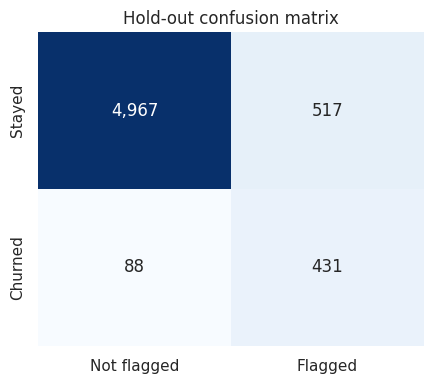

In [9]:
p_test = best_model.predict_proba(X_test)[:, 1]
pred_test = (p_test >= THRESHOLD).astype(int)
base_rate = y_test.mean()

results = pd.Series({
    "Recall (churners caught)": recall_score(y_test, pred_test),
    "Precision (alerts that are real churners)": precision_score(y_test, pred_test),
    "F2-score": fbeta_score(y_test, pred_test, beta=2),
    "PR-AUC": average_precision_score(y_test, p_test),
    "ROC-AUC": roc_auc_score(y_test, p_test),
    "Share of base flagged": pred_test.mean(),
    "Accuracy (reference only)": (pred_test == y_test).mean(),
})
print(results.round(3).to_string())
print(f"\nTest churn rate (random-targeting precision): {base_rate:.2%}")
print(f"Precision lift over random targeting: {results.iloc[1] / base_rate:.1f}x")

cm = confusion_matrix(y_test, pred_test)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Not flagged", "Flagged"], yticklabels=["Stayed", "Churned"])
ax.set_title("Hold-out confusion matrix"); plt.tight_layout(); plt.savefig(IMG_DIR / "confusion_matrix.png", dpi=120); plt.show()

## 8. Explainability with SHAP
SHAP values show how each feature pushes an individual customer's churn score up or down, which is more reliable than
reading Lasso coefficients when features are highly correlated.

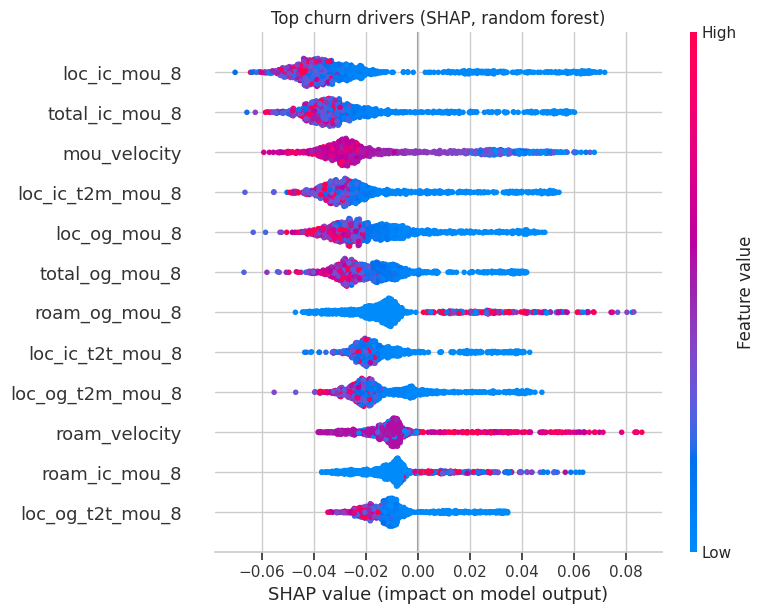

,feature,mean_abs_shap
0,loc_ic_mou_8,0.0367
1,total_ic_mou_8,0.0327
2,mou_velocity,0.0282
3,loc_ic_t2m_mou_8,0.0274
4,loc_og_mou_8,0.0223
5,total_og_mou_8,0.0212
6,roam_og_mou_8,0.0196
7,loc_ic_t2t_mou_8,0.0188
8,loc_og_t2m_mou_8,0.0183
9,roam_velocity,0.0162


In [10]:
clf = best_model.named_steps["clf"]
X_test_capped = pd.DataFrame(best_model.named_steps["cap"].transform(X_test), columns=FEATURES, index=X_test.index)
X_shap = X_test_capped.sample(1000, random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):          # older SHAP: one array per class
    shap_values = shap_values[1]
elif np.ndim(shap_values) == 3:            # newer SHAP: (rows, features, classes)
    shap_values = shap_values[:, :, 1]

shap.summary_plot(shap_values, X_shap, max_display=12, show=False)
plt.title(f"Top churn drivers (SHAP, {best_name.lower()})"); plt.tight_layout()
plt.savefig(IMG_DIR / "shap_summary.png", dpi=120, bbox_inches="tight"); plt.show()

shap_importance = (pd.DataFrame({"feature": FEATURES, "mean_abs_shap": np.abs(shap_values).mean(axis=0)})
                   .sort_values("mean_abs_shap", ascending=False).head(10).reset_index(drop=True))
shap_importance.round(4)

## 9. Cost–benefit of the retention campaign
The model is only useful if acting on it makes money. The assumptions below are deliberately simple and are
**parameters, not facts**; change them to match a real offer.

* **Value saved:** a retained churner keeps paying their good-phase ARPU for `MONTHS_RETAINED` months.
* **Offer cost:** every contacted customer receives an offer worth `OFFER_COST_INR`.
* **Save rate:** `SAVE_RATE` of contacted churners are retained. Non-churners cost the offer but save nothing.

In [11]:
OFFER_COST_INR = 150      # e.g. a bonus data pack
SAVE_RATE = 0.30          # share of contacted churners who stay
MONTHS_RETAINED = 3       # months of ARPU kept per saved churner

test_frame = df.loc[X_test.index, [ID_COL, TARGET, "arpu_good"]].assign(churn_prob=p_test, flagged=pred_test)

def campaign(target_mask):
    contacted = test_frame[target_mask]
    saved_value = (contacted[TARGET] * contacted["arpu_good"]).sum() * SAVE_RATE * MONTHS_RETAINED
    cost = len(contacted) * OFFER_COST_INR
    return {"customers contacted": len(contacted), "churners reached": int(contacted[TARGET].sum()),
            "revenue saved (INR)": saved_value, "offer cost (INR)": cost, "net value (INR)": saved_value - cost}

strategies = pd.DataFrame({
    "No campaign": {k: 0 for k in ["customers contacted", "churners reached", "revenue saved (INR)", "offer cost (INR)", "net value (INR)"]},
    "Contact every HVC": campaign(np.ones(len(test_frame), dtype=bool)),
    "Model-targeted": campaign(test_frame["flagged"] == 1),
}).T
strategies["ROI"] = strategies["net value (INR)"] / strategies["offer cost (INR)"].replace(0, np.nan)
print(strategies.round(2).to_string())
strategies.style.format({c: "{:,.0f}" for c in strategies.columns if c != "ROI"} | {"ROI": "{:.1f}x"})

                   customers contacted  churners reached  revenue saved (INR)  offer cost (INR)  net value (INR)   ROI
No campaign                        0.0               0.0                 0.00               0.0             0.00   NaN
Contact every HVC               6003.0             519.0            285307.32          900450.0       -615142.68 -0.68
Model-targeted                   948.0             431.0            231160.50          142200.0         88960.50  0.63


,customers contacted,churners reached,revenue saved (INR),offer cost (INR),net value (INR),ROI
No campaign,0,0,0,0,0,nanx
Contact every HVC,"6,003",519,"285,307","900,450","-615,143",-0.7x
Model-targeted,948,431,"231,160","142,200","88,960",0.6x


In [12]:
# Sensitivity: net value of the model-targeted campaign across save rates and offer costs
grid = []
for sr in [0.15, 0.30, 0.45]:
    for oc in [100, 150, 250]:
        contacted = test_frame[test_frame["flagged"] == 1]
        net = (contacted[TARGET] * contacted["arpu_good"]).sum() * sr * MONTHS_RETAINED - len(contacted) * oc
        grid.append({"save rate": f"{sr:.0%}", "offer cost (INR)": oc, "net value (INR)": net})
pd.DataFrame(grid).pivot(index="save rate", columns="offer cost (INR)", values="net value (INR)").style.format("{:,.0f}")

offer cost (INR),100,150,250
save rate,,,
15%,"20,780","-26,620","-121,420"
30%,"136,360","88,960","-5,840"
45%,"251,941","204,541","109,741"


## 10. Risk-score export and SQL layer (DuckDB)
The scored hold-out customers are exported for reporting (e.g. a Power BI dashboard), and the operational questions
a retention team would ask are answered in SQL. The same queries are saved in `sql/`.

In [13]:
test_frame["risk_tier"] = pd.cut(test_frame["churn_prob"], [-0.01, THRESHOLD, 0.5, 1.0],
                                 labels=["Low", "Medium", "High"]).astype(str)
test_frame["customer_id"] = np.arange(1, len(test_frame) + 1)   # anonymised ID instead of the phone number
export = test_frame[["customer_id", "churn_prob", "risk_tier", "flagged", "arpu_good", TARGET]].rename(
    columns={"arpu_good": "monthly_arpu_inr", TARGET: "actual_churn"})
export.to_csv(OUT_DIR / "risk_scores.csv", index=False)
print(f"Exported {len(export):,} scored customers to outputs/risk_scores.csv")

con = duckdb.connect()
con.execute("CREATE TABLE risk AS SELECT * FROM read_csv_auto('outputs/risk_scores.csv')")

def run_sql(path):
    return con.execute(Path(path).read_text()).df()

Exported 6,003 scored customers to outputs/risk_scores.csv


In [14]:
# Q1. Revenue at risk by risk tier
run_sql("sql/01_revenue_at_risk_by_tier.sql")

,risk_tier,customers,avg_churn_prob,actual_churners,churn_rate_pct,monthly_arpu_inr,churned_arpu_inr
0,High,495,0.789,321.0,64.8,292355.0,192075.0
1,Medium,453,0.346,110.0,24.3,269944.0,64770.0
2,Low,5055,0.058,88.0,1.7,2968348.0,60163.0


In [15]:
# Q2. Decile lift: how concentrated are churners in the highest-scored customers?
run_sql("sql/02_decile_lift.sql")

,decile,customers,churners,churn_rate_pct,lift,cumulative_churners_captured_pct
0,1,601,360.0,59.9,6.93,69.4
1,2,601,100.0,16.6,1.92,88.6
2,3,601,21.0,3.5,0.40,92.7
3,4,600,14.0,2.3,0.27,95.4
4,5,600,10.0,1.7,0.19,97.3
5,6,600,6.0,1.0,0.12,98.5
6,7,600,3.0,0.5,0.06,99.0
7,8,600,1.0,0.2,0.02,99.2
8,9,600,1.0,0.2,0.02,99.4
9,10,600,3.0,0.5,0.06,100.0


In [16]:
# Q3. Retention call list: highest-value customers among those flagged
run_sql("sql/03_priority_call_list.sql")

,customer_id,risk_tier,churn_prob,monthly_arpu_inr,expected_arpu_at_risk_inr
0,5221,High,0.878,5336.0,4685.0
1,3558,High,0.847,2989.0,2532.0
2,3234,High,0.981,2160.0,2119.0
3,4244,High,0.764,2658.0,2032.0
4,1339,High,0.989,2025.0,2003.0
5,810,High,0.968,1790.0,1733.0
6,3595,High,0.785,2095.0,1644.0
7,2733,High,0.935,1697.0,1586.0
8,4011,High,0.974,1378.0,1343.0
9,679,High,0.894,1461.0,1306.0


## Summary
* The headline metrics above come from a test set that was not used for training, model choice or threshold selection.
* The cost–benefit table turns those metrics into a campaign decision; its assumptions should be replaced with real offer data before use.
* See `README.md` for the written summary of results and limitations.